### Read data

In [1]:
import urllib.request
import json
import pandas as pd

url = 'https://admin.opendata.az/api/3/action/package_show?id=stansiyalar-uzre-gundelik-sernisin-gedislerinin-sayi'

with urllib.request.urlopen(url) as response:
    data = json.loads(response.read().decode())

# Strukturu anlamaq üçün
print(data['success'])        # True olmalıdır
print(data['result'].keys())  # Hansı fieldlər var

True
dict_keys(['author', 'author_email', 'author_translated', 'creator_user_id', 'id', 'isopen', 'license_id', 'license_title', 'license_url', 'maintainer', 'maintainer_email', 'maintainer_translated', 'metadata_created', 'metadata_modified', 'name', 'notes', 'notes_translated', 'num_resources', 'num_tags', 'organization', 'owner_org', 'private', 'state', 'title', 'title_translated', 'type', 'url', 'version', 'resources', 'tags', 'groups', 'relationships_as_subject', 'relationships_as_object', 'rating', 'ratings_count', 'total_downloads'])


In [2]:
resources = data['result']['resources']

for r in resources:
    print(r['name'], '|', r['format'], '|', r['url'])

2025-ci ildə stansiyalar üzrə gündəlik sərnişin gedişlərinin sayı  | CSV | https://admin.opendata.az/dataset/66051a52-1172-4c59-8ea2-1062562c991f/resource/7f84c392-bee9-4fce-8fde-d60e53520913/download/passenger_2025.csv
2026-ci ildə (Yanvar, Fevral) stansiyalar üzrə gündəlik sərnişin gedişlərinin sayı  | CSV | https://admin.opendata.az/dataset/66051a52-1172-4c59-8ea2-1062562c991f/resource/01d12a6f-c4d9-4bb3-a0e2-01b244ca9c00/download/passenger_2026.csv


In [3]:
csv_url = resources[0]['url']  # ilk resursu götür
df = pd.read_csv(csv_url)
df.head()

,Tarix (gün.ay.il);Stansiya;Gündəlik gediş sayı
2025-01-01 00:00:00,"000;""20 Yanvar"";29406"
2025-01-02 00:00:00,"000;""20 Yanvar"";31045"
2025-01-03 00:00:00,"000;""20 Yanvar"";33650"
2025-01-04 00:00:00,"000;""20 Yanvar"";34509"
2025-01-05 00:00:00,"000;""20 Yanvar"";28789"


In [4]:
import urllib.request
import json
import pandas as pd
from io import StringIO

url = 'https://admin.opendata.az/api/3/action/package_show?id=stansiyalar-uzre-gundelik-sernisin-gedislerinin-sayi'

with urllib.request.urlopen(url) as response:
    data = json.loads(response.read().decode())

csv_url = data['result']['resources'][0]['url']

# CSV-i oxu - separator nöqtəli vergüldür
with urllib.request.urlopen(csv_url) as r:
    content = r.read().decode('utf-8')

df = pd.read_csv(StringIO(content), sep=';')

print(df.columns.tolist())  # sütun adlarına bax
print(df.head())

['Tarix (gün.ay.il)', 'Stansiya', 'Gündəlik gediş sayı']
         Tarix (gün.ay.il)   Stansiya  Gündəlik gediş sayı
0  2025-01-01 00:00:00,000  20 Yanvar                29406
1  2025-01-02 00:00:00,000  20 Yanvar                31045
2  2025-01-03 00:00:00,000  20 Yanvar                33650
3  2025-01-04 00:00:00,000  20 Yanvar                34509
4  2025-01-05 00:00:00,000  20 Yanvar                28789


In [5]:
print(df.columns.tolist())
print(df.head(3))

['Tarix (gün.ay.il)', 'Stansiya', 'Gündəlik gediş sayı']
         Tarix (gün.ay.il)   Stansiya  Gündəlik gediş sayı
0  2025-01-01 00:00:00,000  20 Yanvar                29406
1  2025-01-02 00:00:00,000  20 Yanvar                31045
2  2025-01-03 00:00:00,000  20 Yanvar                33650


In [7]:
df.columns = ['Tarix', 'Stansiya', 'Gedis_sayi']
df['Tarix'] = pd.to_datetime(df['Tarix']).dt.date

C:\Users\Ali\AppData\Local\Temp\ipykernel_13844\2718853349.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Tarix'] = pd.to_datetime(df['Tarix']).dt.date


In [8]:
df

,Tarix,Stansiya,Gedis_sayi
0,2025-01-01,20 Yanvar,29406
1,2025-01-02,20 Yanvar,31045
2,2025-01-03,20 Yanvar,33650
3,2025-01-04,20 Yanvar,34509
4,2025-01-05,20 Yanvar,28789
...,...,...,...
9850,2025-12-27,Ulduz,6684
9851,2025-12-28,Ulduz,4213
9852,2025-12-29,Ulduz,9009
9853,2025-12-30,Ulduz,8409


In [10]:
print(df.columns.tolist())


['Tarix', 'Stansiya', 'Gedis_sayi']


### Gedis sayi umumi

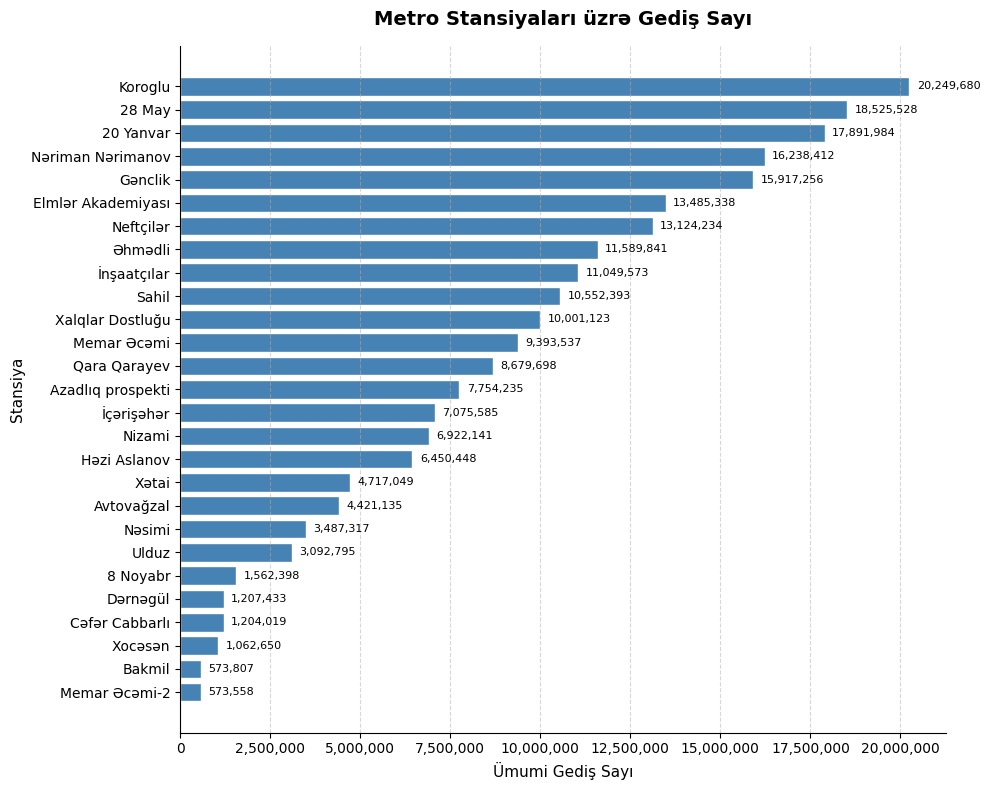

In [24]:
stansiya_df = df.groupby('Stansiya')['Gedis_sayi'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(stansiya_df.index, stansiya_df.values, color='steelblue', edgecolor='white')

for bar, val in zip(bars, stansiya_df.values):
    ax.text(val + stansiya_df.values.max() * 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=8)

ax.set_title('Metro Stansiyaları üzrə Gediş Sayı', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Ümumi Gediş Sayı', fontsize=11)
ax.set_ylabel('Stansiya', fontsize=11)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Aylıq trend (line chart)

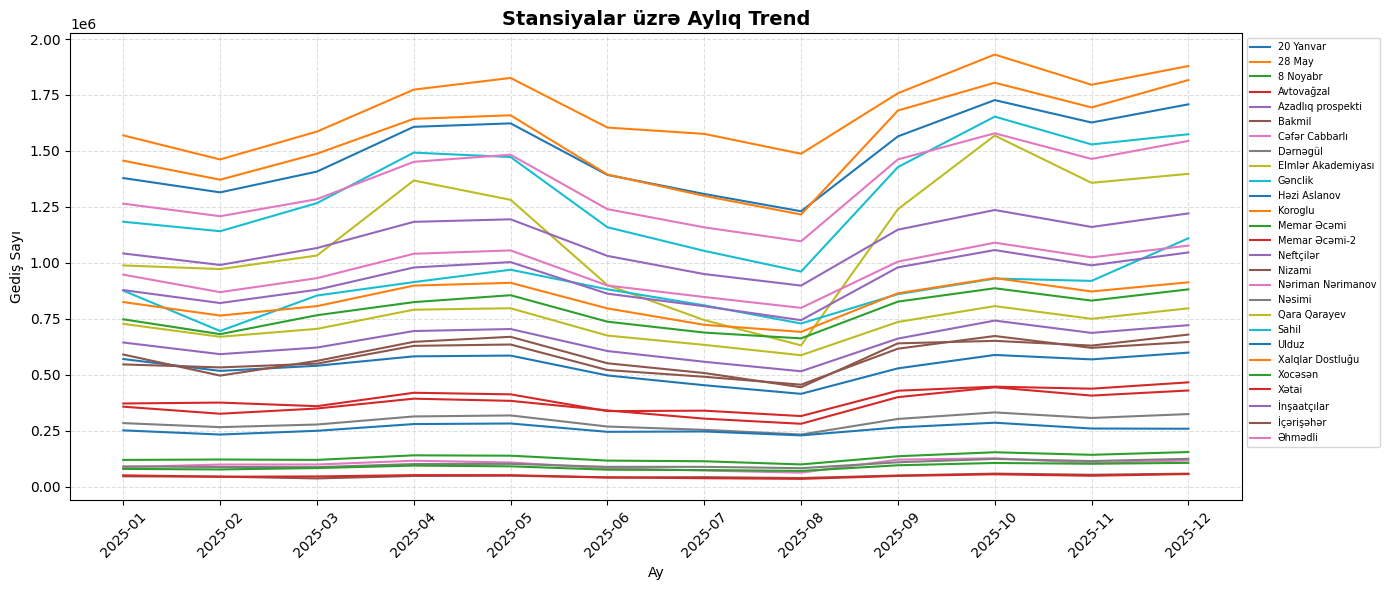

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

df['Tarix'] = pd.to_datetime(df['Tarix'])
df['Ay'] = df['Tarix'].dt.to_period('M')

trend_df = df.groupby(['Ay', 'Stansiya'])['Gedis_sayi'].sum().reset_index()
trend_df['Ay'] = trend_df['Ay'].astype(str)

fig, ax = plt.subplots(figsize=(14, 6))
for stansiya, group in trend_df.groupby('Stansiya'):
    ax.plot(group['Ay'], group['Gedis_sayi'], label=stansiya, linewidth=1.5)

ax.set_title('Stansiyalar üzrə Aylıq Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Ay')
ax.set_ylabel('Gediş Sayı')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=7)
ax.tick_params(axis='x', rotation=45)
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

2. Həftə günləri analizi


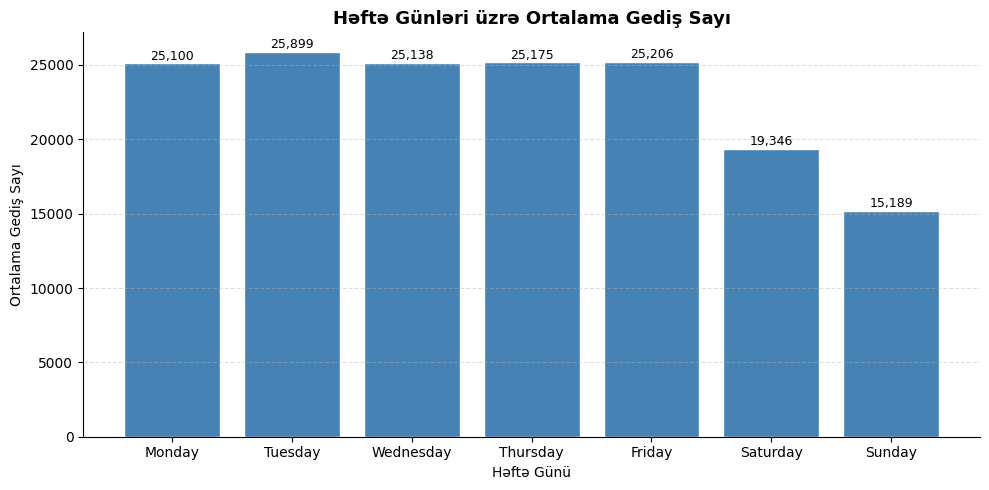

In [13]:
df['HeftaGunu'] = pd.to_datetime(df['Tarix']).dt.day_name()
gun_sirasi = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
gun_df = df.groupby('HeftaGunu')['Gedis_sayi'].mean().reindex(gun_sirasi)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(gun_df.index, gun_df.values, color='steelblue', edgecolor='white')
for bar, val in zip(bars, gun_df.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + gun_df.values.max()*0.01,
            f'{int(val):,}', ha='center', fontsize=9)
ax.set_title('Həftə Günləri üzrə Ortalama Gediş Sayı', fontsize=13, fontweight='bold')
ax.set_xlabel('Həftə Günü')
ax.set_ylabel('Ortalama Gediş Sayı')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

3. Heatmap — Stansiya × Ay


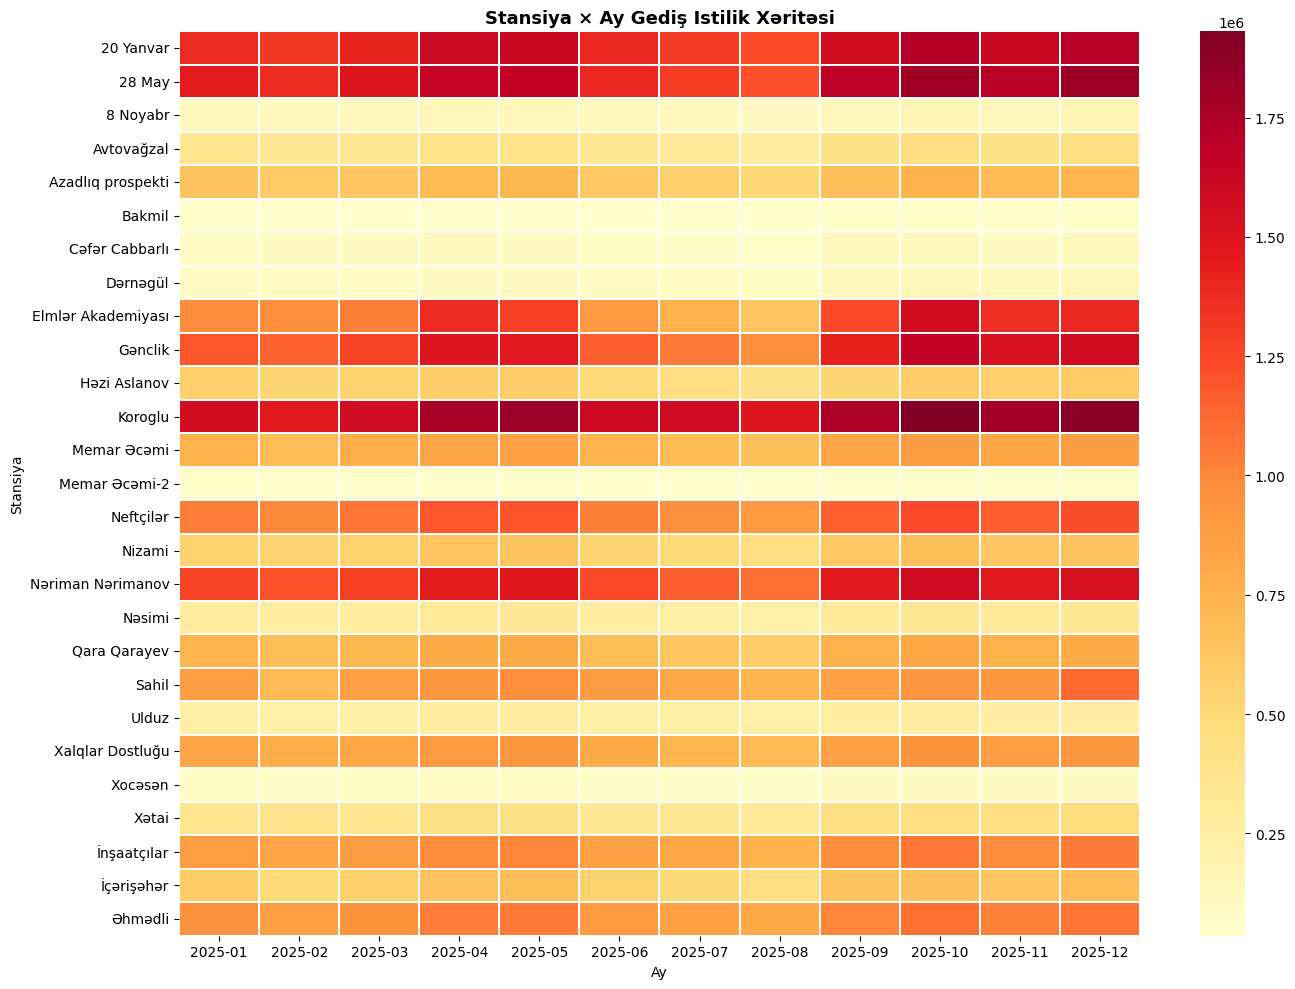

In [14]:
import seaborn as sns

df['Ay'] = pd.to_datetime(df['Tarix']).dt.to_period('M').astype(str)
heat_df = df.groupby(['Stansiya', 'Ay'])['Gedis_sayi'].sum().unstack()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(heat_df, cmap='YlOrRd', fmt='.0f', linewidths=0.3, ax=ax)
ax.set_title('Stansiya × Ay Gediş Istilik Xəritəsi', fontsize=13, fontweight='bold')
ax.set_xlabel('Ay')
ax.set_ylabel('Stansiya')
plt.tight_layout()
plt.show()

4. Ranking — Ən yüklü / sakit stansiyalar


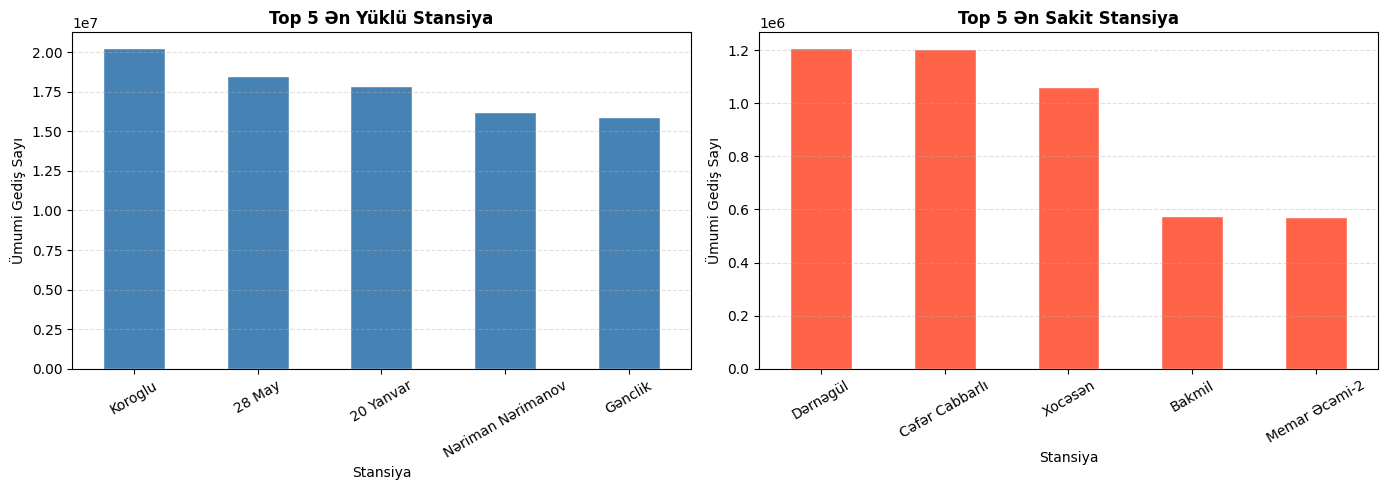

In [16]:
ranking = df.groupby('Stansiya')['Gedis_sayi'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ranking.head(5).plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Top 5 Ən Yüklü Stansiya', fontweight='bold')
axes[0].set_ylabel('Ümumi Gediş Sayı')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

ranking.tail(5).plot(kind='bar', ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title('Top 5 Ən Sakit Stansiya', fontweight='bold')
axes[1].set_ylabel('Ümumi Gediş Sayı')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

5. Anomaliya aşkarlanması


In [17]:
from scipy import stats

df['Z_score'] = df.groupby('Stansiya')['Gedis_sayi'].transform(
    lambda x: stats.zscore(x, nan_policy='omit')
)
anomaliyalar = df[df['Z_score'].abs() > 2.5].sort_values('Z_score', ascending=False)
print(f"Anomaliya sayı: {len(anomaliyalar)}")
print(anomaliyalar[['Tarix', 'Stansiya', 'Gedis_sayi', 'Z_score']].head(10))

Anomaliya sayı: 22
          Tarix        Stansiya  Gedis_sayi   Z_score
9436 2025-11-08           Sahil       54725  4.793790
7305 2025-01-06   Memar Əcəmi-2        3410  4.225769
7307 2025-01-08   Memar Əcəmi-2        3273  3.910895
7634 2025-12-01   Memar Əcəmi-2        3180  3.697148
5732 2025-09-15      İçərişəhər       35405  3.242174
2447 2025-09-15  Cəfər Cabbarlı        7972  3.076612
5733 2025-09-16      İçərişəhər       34469  3.052742
9125 2025-01-01           Sahil       44964  2.981147
5735 2025-09-18      İçərişəhər       34037  2.965311
5736 2025-09-19      İçərişəhər       33894  2.936370


6. Klasterləşdirmə — oxşar stansiyalar


In [20]:
import sys
!{sys.executable} -m pip install scikit-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.0 MB 3.8 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.0 MB 5.5 MB/s eta 0:00:02
   ----------------- ---------------------- 3.4/8.0 MB 5.2 MB/s eta 0:00:01
   ---------------------- ----------------- 4.5/8.0 MB 5.4 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.0 MB 5.4 MB/s eta 0:00:01
   ----------------------------------- ---- 7.1/8.0 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 5.5 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

pivot = df.groupby(['Stansiya', 'Ay'])['Gedis_sayi'].sum().unstack(fill_value=0)
scaler = StandardScaler()
scaled = scaler.fit_transform(pivot)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
pivot['Klaster'] = kmeans.fit_predict(scaled)

print(pivot[['Klaster']].sort_values('Klaster'))

Ay                  Klaster
Stansiya                   
Azadlıq prospekti         0
Nizami                    0
Memar Əcəmi               0
Həzi Aslanov              0
İnşaatçılar               0
Xalqlar Dostluğu          0
Qara Qarayev              0
Sahil                     0
Əhmədli                   0
İçərişəhər                0
Neftçilər                 1
Gənclik                   1
Elmlər Akademiyası        1
20 Yanvar                 1
28 May                    1
Koroglu                   1
Nəriman Nərimanov         1
Bakmil                    2
Memar Əcəmi-2             2
8 Noyabr                  2
Avtovağzal                2
Dərnəgül                  2
Cəfər Cabbarlı            2
Nəsimi                    2
Xətai                     2
Xocəsən                   2
Ulduz                     2


7. Proqnozlaşdırma — Prophet


12:33:51 - cmdstanpy - INFO - Chain [1] start processing
12:33:52 - cmdstanpy - INFO - Chain [1] done processing


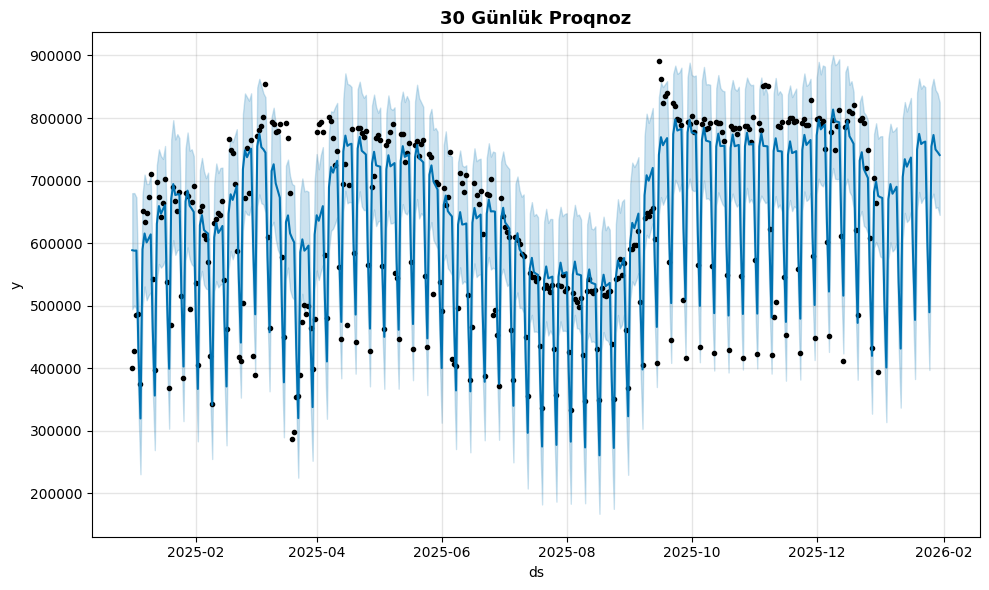

In [19]:
# Əvvəlcə install et (bir dəfə):
# pip install prophet

from prophet import Prophet

# Ümumi gündəlik gediş (bütün stansiyalar)
prophet_df = df.groupby('Tarix')['Gedis_sayi'].sum().reset_index()
prophet_df.columns = ['ds', 'y']
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])

model = Prophet(yearly_seasonality=True, weekly_seasonality=True)
model.fit(prophet_df)

future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

model.plot(forecast)
plt.title('30 Günlük Proqnoz', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()